# 02 — Basic Pitch internals

Inspect the model's raw output: note, onset, and contour posteriorgrams, and how thresholds change the decoded notes.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "tests").exists():
    ROOT = ROOT.parent
AUDIO_DIR = ROOT / "tests" / "fixtures" / "audio"
GOLDEN_DIR = ROOT / "tests" / "fixtures" / "golden"
print("project root:", ROOT)


project root: /home/anton/Projects/music-teacher


In [2]:
from music_teacher.transcription.audio import load_audio
from music_teacher.transcription.onnx_engine import BasicPitchEngine

engine = BasicPitchEngine(device="auto")
engine.warmup()
print("providers:", engine.active_providers)
audio = load_audio(AUDIO_DIR / "flute_melody.wav")
output = engine.predict(audio)
for key, value in output.items():
    print(f"{key:8} {value.shape}")


providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
note     (323, 88)
onset    (323, 88)
contour  (323, 264)


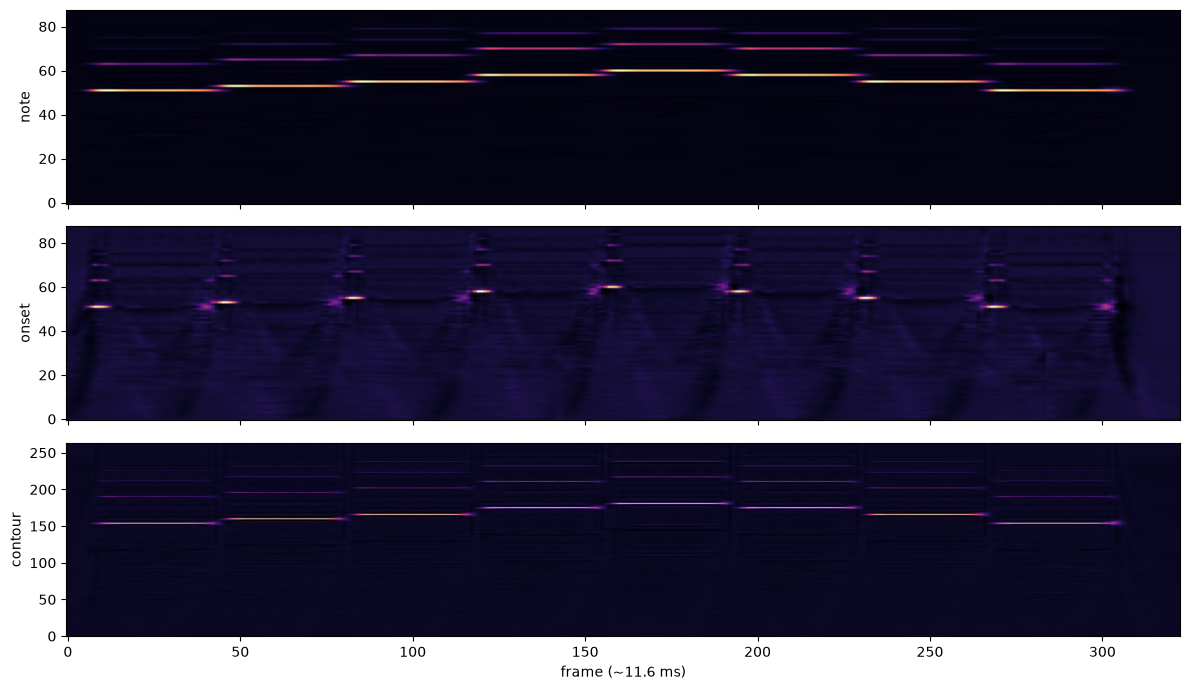

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for ax, key in zip(axes, ("note", "onset", "contour")):
    ax.imshow(output[key].T, origin="lower", aspect="auto", cmap="magma")
    ax.set_ylabel(key)
axes[-1].set_xlabel("frame (~11.6 ms)")
fig.tight_layout()


In [4]:
from music_teacher.transcription.notes import model_output_to_notes, filter_harmonic_duplicates

for onset_threshold in (0.3, 0.5, 0.7):
    for frame_threshold in (0.2, 0.3, 0.4):
        events = model_output_to_notes(output, onset_threshold=onset_threshold, frame_threshold=frame_threshold)
        filtered = filter_harmonic_duplicates(events)
        print(f"onset={onset_threshold} frame={frame_threshold}: raw={len(events):2d} filtered={len(filtered):2d}")


onset=0.3 frame=0.2: raw=16 filtered= 8
onset=0.3 frame=0.3: raw=15 filtered= 8
onset=0.3 frame=0.4: raw=11 filtered= 8
onset=0.5 frame=0.2: raw=16 filtered= 8
onset=0.5 frame=0.3: raw=15 filtered= 8
onset=0.5 frame=0.4: raw=11 filtered= 8
onset=0.7 frame=0.2: raw=16 filtered= 8
onset=0.7 frame=0.3: raw=15 filtered= 8
onset=0.7 frame=0.4: raw=11 filtered= 8


In [5]:
events = filter_harmonic_duplicates(model_output_to_notes(output))
for event in events:
    print(f"{event.start:6.2f}s -> {event.end:6.2f}s  pitch={event.pitch:3d}  velocity={event.velocity:.2f}")


  0.08s ->   0.52s  pitch= 72  velocity=0.74
  0.52s ->   0.95s  pitch= 74  velocity=0.73
  0.96s ->   1.38s  pitch= 76  velocity=0.76
  1.38s ->   1.82s  pitch= 79  velocity=0.75
  1.81s ->   2.24s  pitch= 81  velocity=0.74
  2.25s ->   2.67s  pitch= 79  velocity=0.76
  2.65s ->   3.09s  pitch= 76  velocity=0.75
  3.10s ->   3.55s  pitch= 72  velocity=0.74


**Lab idea:** add your own post-processing functions to `notes.py`, then re-run `scripts/evaluate.py` to see whether they help.